# Import

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
#from cartopy import crs as ccrs
#from cartopy import feature as cfeature
from datetime import datetime,timedelta
#from dateutil.relativedelta import relativedelta

import geopandas as gpd
from lonboard import viz, Map, ScatterplotLayer, HeatmapLayer
import duckdb

By default, set the date and time to one hour prior to the current time. Or, specify a past date and hour.

Call time by querying

In [2]:
# Use the current time, or set your own for a past time.
# Set current to False if you want to specify a past time.

nowTime = datetime.now()

current = True
current = False
if (current):
    validTime = datetime.now()
    year = validTime.year
    month = validTime.month
    day = validTime.day
    hour = validTime.hour
    validTime = datetime(year, month, day, hour)
    offset = timedelta(hours = 1)
    validTime = validTime - offset
else:
    year = 2026
    month = 1
    day = 1
    hour = 0
    time_1 = datetime(year, month, day, hour)

In [3]:
time_0 = time_1 - timedelta(hours=1)
YYYY_0 = time_0.strftime("%Y")
YYYY_1 = time_1.strftime("%Y")
print(time_0, time_1)
# Handle edge case when the two hours straddle the end/beginning of a yearw
if (YYYY_0 == YYYY_1):
    URLs = [f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_1}/data.parquet']
else:
    URLs = [f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_0}/data.parquet',
            f'https://data.source.coop/dynamical/asos-parquet/year={YYYY_1}/data.parquet']


2025-12-31 23:00:00 2026-01-01 00:00:00


In [4]:
URLs

['https://data.source.coop/dynamical/asos-parquet/year=2025/data.parquet',
 'https://data.source.coop/dynamical/asos-parquet/year=2026/data.parquet']

In [5]:
df = duckdb.execute("""
    SELECT *
    FROM read_parquet($1, hive_partitioning=true)
    WHERE 
---      country = 'FR' AND
    valid BETWEEN $2 AND $3
    ORDER BY country
""", [URLs, time_0, time_1]).fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
df

,station,valid,longitude,latitude,tmpf,tmpc,dwpf,dwpc,relh,drct,...,state,name,elevation,country,county,wfo,tzname,geometry,bbox,year
0,YCIN,2025-12-31 23:00:00+00:00,123.8283,-17.5814,84.2,29.0,78.8,26.0,83.93,240.0,...,AU,Derby,91.0,AU,NaN,NaN,Australia/Perth,"[1, 1, 0, 0, 0, 183, 209, 0, 222, 2, 245, 94, ...","{'xmin': 123.8283, 'ymin': -17.5814, 'xmax': 1...",2025
1,YPGV,2025-12-31 23:30:00+00:00,136.8183,-12.2694,86.0,30.0,75.2,24.0,70.35,300.0,...,AU,Gove,55.0,AU,NaN,NaN,Australia/Darwin,"[1, 1, 0, 0, 0, 35, 74, 123, 131, 47, 26, 97, ...","{'xmin': 136.8183, 'ymin': -12.2694, 'xmax': 1...",2025
2,YSSY,2025-12-31 23:30:00+00:00,151.1731,-33.9465,64.4,18.0,62.6,17.0,93.89,180.0,...,AU,Sydney,3.0,AU,NaN,NaN,Australia/Sydney,"[1, 1, 0, 0, 0, 1, 222, 2, 9, 138, 229, 98, 64...","{'xmin': 151.1731, 'ymin': -33.9465, 'xmax': 1...",2025
3,YSTW,2025-12-31 23:00:00+00:00,150.8467,-31.0839,80.6,27.0,55.4,13.0,42.03,320.0,...,AU,Tamworth,410.0,AU,NaN,NaN,Australia/Sydney,"[1, 1, 0, 0, 0, 190, 48, 153, 42, 24, 219, 98,...","{'xmin': 150.8467, 'ymin': -31.0839, 'xmax': 1...",2025
4,YBHM,2026-01-01 00:00:00+00:00,148.9517,-20.3581,82.4,28.0,69.8,21.0,65.82,100.0,...,AU,Hamilton Island,5.0,AU,NaN,NaN,Australia/Lindeman,"[1, 1, 0, 0, 0, 77, 243, 142, 83, 116, 158, 98...","{'xmin': 148.9517, 'ymin': -20.3581, 'xmax': 1...",2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,FAGG,2025-12-31 23:43:00+00:00,22.3789,-34.0055,68.0,20.0,68.0,20.0,100.00,0.0,...,ZA,George,193.0,ZA,NaN,NaN,Africa/Johannesburg,"[1, 1, 0, 0, 0, 84, 116, 36, 151, 255, 96, 54,...","{'xmin': 22.3789, 'ymin': -34.0055, 'xmax': 22...",2025
7783,FAGG,2025-12-31 23:17:00+00:00,22.3789,-34.0055,68.0,20.0,68.0,20.0,100.00,190.0,...,ZA,George,193.0,ZA,NaN,NaN,Africa/Johannesburg,"[1, 1, 0, 0, 0, 84, 116, 36, 151, 255, 96, 54,...","{'xmin': 22.3789, 'ymin': -34.0055, 'xmax': 22...",2025
7784,FALE,2025-12-31 23:00:00+00:00,31.1300,-29.6017,71.6,22.0,68.0,20.0,88.45,NaN,...,ZA,Durban,109.0,ZA,NaN,NaN,Africa/Johannesburg,"[1, 1, 0, 0, 0, 225, 122, 20, 174, 71, 33, 63,...","{'xmin': 31.13, 'ymin': -29.6017, 'xmax': 31.1...",2025
7785,FACT,2025-12-31 23:00:00+00:00,18.6000,-33.9667,68.0,20.0,66.2,19.0,93.98,200.0,...,ZA,Cape Town,42.0,ZA,NaN,NaN,Africa/Johannesburg,"[1, 1, 0, 0, 0, 154, 153, 153, 153, 153, 153, ...","{'xmin': 18.6, 'ymin': -33.9667, 'xmax': 18.6,...",2025


tmpc: Temperature in degrees Celsius

In [7]:
from numpy.random import default_rng
from pandas import Series, MultiIndex

rng = default_rng(0)

country = [ 'ZA', 'MX', 'CA', 'RU', 'KR', 'DE', 'BR', 'CN', 'GB', 'US', 'AU', 'IN', 'JP', 'FR']
years = (df['valid'])

index = MultiIndex.from_product([country, years], names=['country', 'valid'])
s = Series(rng.integers(20, 100, size=len(index)), index=index, name='count')

s

country  valid                    
ZA       2025-12-31 23:00:00+00:00    88
         2025-12-31 23:30:00+00:00    70
         2025-12-31 23:30:00+00:00    60
         2025-12-31 23:00:00+00:00    41
         2026-01-01 00:00:00+00:00    44
                                      ..
FR       2025-12-31 23:43:00+00:00    25
         2025-12-31 23:17:00+00:00    84
         2025-12-31 23:00:00+00:00    67
         2025-12-31 23:00:00+00:00    59
         2026-01-01 00:00:00+00:00    57
Name: count, Length: 109018, dtype: int64

The Data

In [8]:
from numpy.random import default_rng
from pandas import Series, MultiIndex

#rng = default_rng(0)

country = ['ZA', 'MX', 'CA', 'RU', 'KR', 'DE', 'BR', 'CN', 'GB', 'US', 'AU', 'IN', 'JP', 'FR']
valid = [2000, 2005, 2010, 2015, 2020, 2025]

index = MultiIndex.from_product([country, valid], names=['country', 'valid'])
s = Series(rng.integers(20, 100, size=len(index)), index=index, name='count')

s

country  valid
ZA       2000     80
         2005     97
         2010     38
         2015     97
         2020     31
                  ..
FR       2005     39
         2010     48
         2015     75
         2020     22
         2025     53
Name: count, Length: 84, dtype: int64

# Bar charts of counting the readings every 5 years from country between 2000 to 2025

/tmp/ipykernel_2223/3797966388.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([t.get_text().title() for t in ax.get_xticklabels()]);


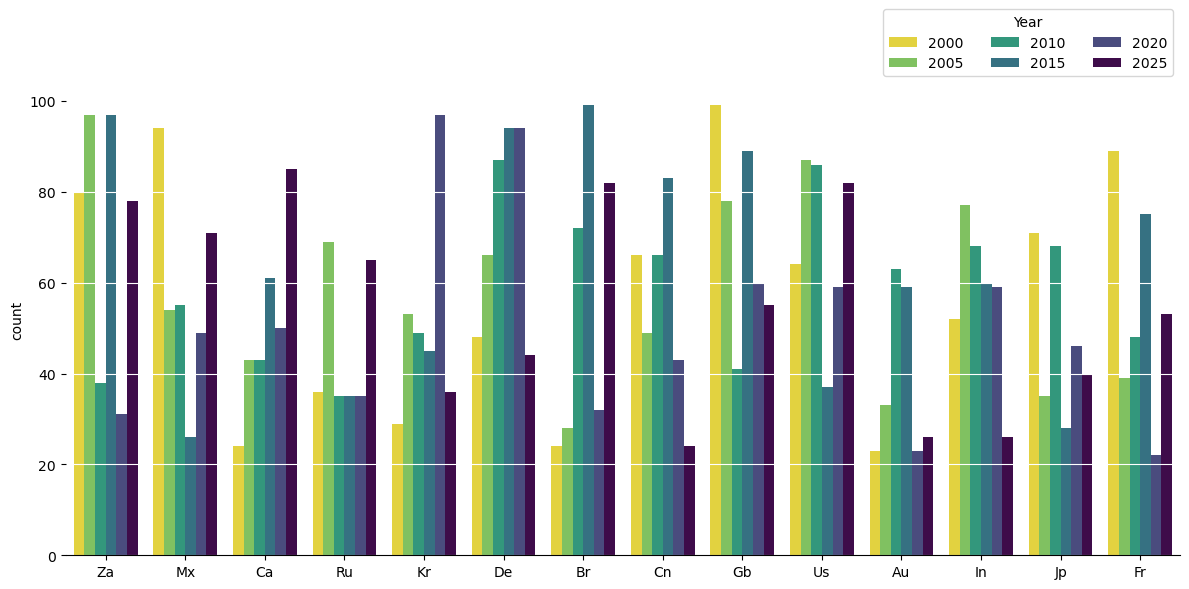

In [9]:
from seaborn import barplot

fig, ax = plt.subplots(figsize=(12, 6))

barplot(
    data=s.reset_index(),
    x='country', y='count', hue='valid',
    hue_order=years, palette='viridis_r',
    ax=ax
)
#bars = ax.barh(df['country'], df['tmpc'], color='#4682b4')
ax.legend(ncol=3, title='Year', loc='lower right', bbox_to_anchor=(1, 1))

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.grid(color=ax.get_facecolor())
ax.set_xticklabels([t.get_text().title() for t in ax.get_xticklabels()]);
ax.set_xlabel('');
plt.tight_layout()
#plt.savefig('Temp2.pdf', bbox_inches='tight')
# 5. Show the plot
plt.show()

# Temperature reading between 2025-12-31 23:00:00 and 2026-01-01 00:00:00 across country stations

<>:6: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:6: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_2223/3216971234.py:6: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_xlabel('Temp ($^\circ$C)', fontsize=12)


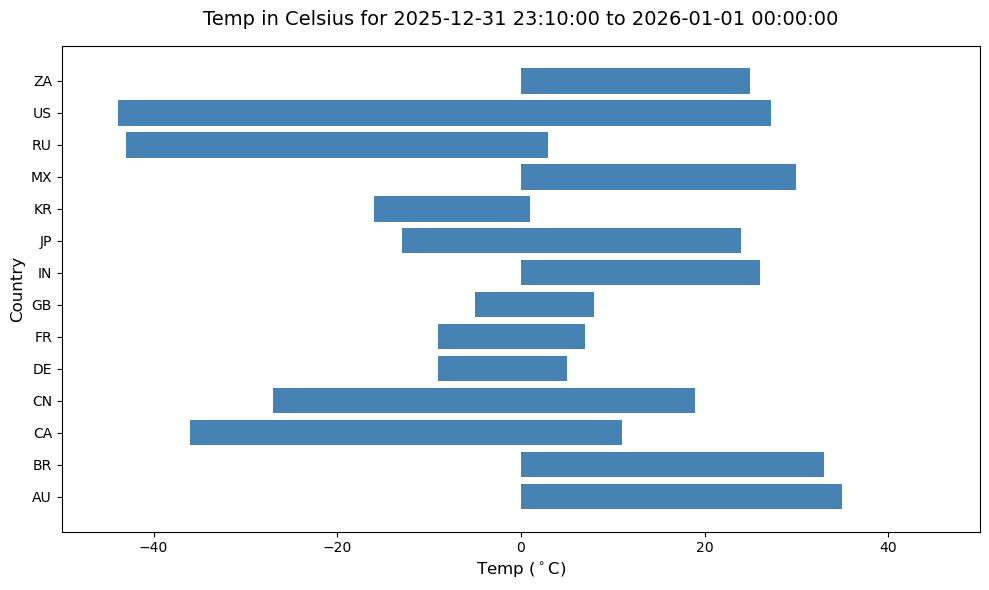

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df['country'], df['tmpc'], color='#4682b4')

ax.set_title('Temp in Celsius for 2025-12-31 23:10:00 to 2026-01-01 00:00:00', fontsize=14, pad=15)
ax.set_xlabel('Temp ($^\circ$C)', fontsize=12)
ax.set_xlim(-50, 50)
ax.set_ylabel('Country', fontsize=12)

plt.tight_layout()

# 5. Show the plot
plt.show()

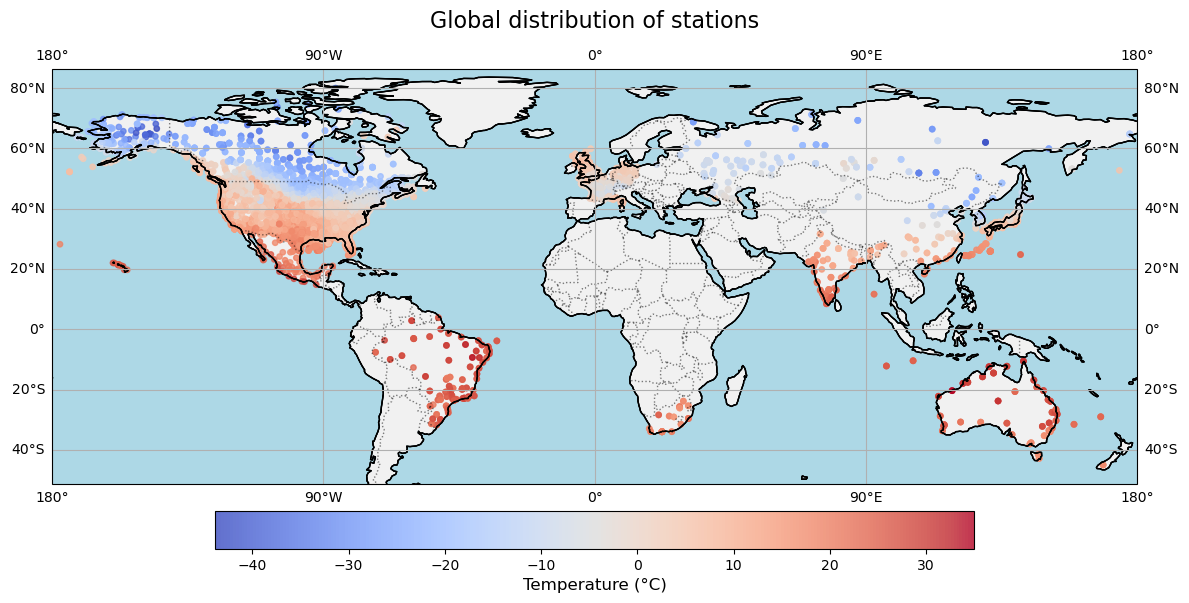

In [11]:
import pandas as pd
import fsspec
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Load Parquet Data from URL
# parquet_url = "https://data.source.coop/dynamical/asos-parquet/year=2025/data.parquet" # Replace with your actual URL
# with fsspec.open(parquet_url) as file:
#     df = pd.read_parquet(file)

# 2. Set up Matplotlib Figure with Plate Carree projection
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Plot the temperature data (assuming columns: 'longitude', 'latitude', 'temperature')
scatter = ax.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['tmpc'],  # The temperature parameter
    cmap='coolwarm',      # Colormap for temperature (blue = cold, red = hot)
    s=15,                 # Marker size
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

# 4. Add map features for context
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.OCEAN, color='lightblue')


# 4. Add geographic visual anchors
ax.coastlines(resolution="110m", color="black", linewidth=1)
ax.gridlines(draw_labels=True, dms=True, xlocs=[-180, -90, 0, 90, 180])

# 5. Add a colorbar and title
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Temperature (°C)', fontsize=12)
plt.title('Global distribution of stations', fontsize=16, pad=15)

# Display the map
plt.show()

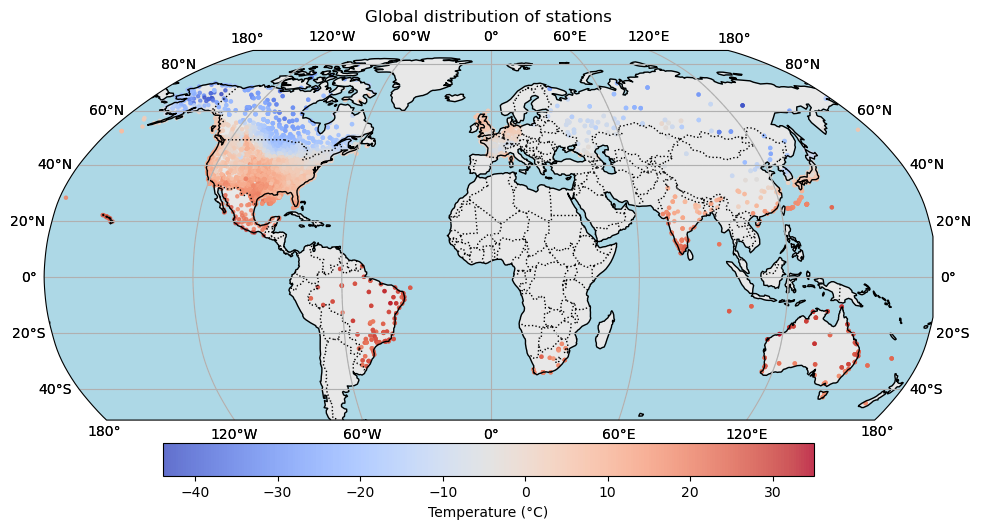

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Load data from Parquet
# Ensure your Parquet file has columns named 'lat', 'lon', and 'temperature'
#df = pd.read_csv('global_temperature_data.parquet') 

# 2. Setup the figure and map projection (Flat Globe / Robinson)
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=0))

# 3. Plot the temperature data
# We use a scatter plot, mapping longitude/latitude to the globe
scatter = ax.scatter(
    df['longitude'], df['latitude'], 
    c=df['tmpc'], 
    cmap='coolwarm', 
    s=5, # Marker size
    alpha=0.8,
    transform=ccrs.PlateCarree() # Specifies that the data's original coordinates are lat/lon
)

# 4. Add geographic context and formatting
ax.coastlines(color='black', linewidth=1)
ax.gridlines(draw_labels=True, linestyle='--', color='lightgray')
ax.gridlines(draw_labels=True, dms=True, xlocs=[-180, -120, -60, 0, 60, 120, 180])
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue')

# 5. Add a colorbar and title
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Temperature (°C)')
plt.title('Global distribution of stations')

# Show the plot
plt.show()
